Cell 4.1 — Kiểm tra PyTorch có nhận CUDA/GPU không

In [1]:
# =========================
# FIX: CÀI PYTORCH BẢN CUDA (GPU) TRÊN WINDOWS
# =========================

# 1) Gỡ bản CPU đang có
%pip uninstall -y torch torchvision torchaudio

# 2) Cài lại bản CUDA (theo PyTorch get-started)
%pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126


Found existing installation: torch 2.9.1+cu126
Uninstalling torch-2.9.1+cu126:
  Successfully uninstalled torch-2.9.1+cu126
Found existing installation: torchvision 0.24.1+cu126
Uninstalling torchvision-0.24.1+cu126:
  Successfully uninstalled torchvision-0.24.1+cu126
Found existing installation: torchaudio 2.9.1+cu126
Uninstalling torchaudio-2.9.1+cu126:
  Successfully uninstalled torchaudio-2.9.1+cu126
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached https://download.pytorch.org/whl/cu126/torch-2.9.1%2Bcu126-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchvision-0.24.1%2Bcu126-cp311-cp311-win_amd64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cu126/torchaudio-2.9.1%2Bcu126-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached https://download.pyto

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.5 which is incompatible.


In [2]:
# =========================
# CELL 4.1: KIỂM TRA GPU (PYTORCH CUDA)
# =========================
import torch

print("torch.__version__      =", torch.__version__)
print("torch.version.cuda     =", torch.version.cuda)
print("cuda available?        =", torch.cuda.is_available())
print("cuda device count      =", torch.cuda.device_count())

if torch.cuda.is_available():
    device_id = 0
    name = torch.cuda.get_device_name(device_id)
    prop = torch.cuda.get_device_properties(device_id)
    vram_gb = prop.total_memory / (1024**3)
    print("GPU name               =", name)
    print(f"VRAM total             = {vram_gb:.2f} GB")
    print("Compute capability     =", f"{prop.major}.{prop.minor}")
    print("cuDNN enabled?         =", torch.backends.cudnn.enabled)
    print("cuDNN version          =", torch.backends.cudnn.version())
else:
    print("\n⚠️ PyTorch chưa dùng được GPU.")
    print("Gợi ý: nhiều khả năng bạn đang cài torch CPU-only hoặc mismatch build.")


torch.__version__      = 2.9.1+cu126
torch.version.cuda     = 12.6
cuda available?        = True
cuda device count      = 1
GPU name               = NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total             = 4.00 GB
Compute capability     = 8.6
cuDNN enabled?         = True
cuDNN version          = 91002


Cell 4.2 (1 cell) — Cài roboflow (nếu cần) + tải dataset vào datasets/

In [3]:
# =========================
# CELL 4.2: DOWNLOAD DATASET TỪ ROBOFLOW (YOLO FORMAT)
# =========================
import os
from roboflow import Roboflow

# (Khuyến nghị) lưu dataset trong thư mục datasets của project
os.makedirs("datasets", exist_ok=True)
os.chdir("datasets")

API_KEY = "peiXx2vQKSUi8zHxksqS"   # <-- DÁN API KEY CỦA BẠN VÀO ĐÂY

rf = Roboflow(api_key=API_KEY)

# Theo link bạn gửi:
# workspace: vietnamtrafficsign
# project  : vietnam-traffic-sign
# version  : 1
project = rf.workspace("vietnamtrafficsign").project("vietnam-traffic-sign")
dataset = project.version(1).download("yolov8")  # YOLO11 dùng chung format YOLO

print("✅ Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
✅ Dataset downloaded to: d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\Vietnam-Traffic-Sign-1


Cell 4.3 (1 cell) — đọc YAML + kiểm tra folder + đếm ảnh

In [4]:
# =========================
# FIX DATA.YAML PATHS (ROBoflow sometimes exports ../train/images)
# Tạo data_fixed.yaml để train cho chắc
# =========================
from pathlib import Path
import yaml

DATASET_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1")

# 1) Dò nhanh xem có các folder images ở đâu
candidates = list(DATASET_DIR.rglob("images"))
print("Found images folders:")
for p in candidates:
    print(" -", p)

# 2) Ưu tiên cấu trúc chuẩn: <DATASET_DIR>/<split>/images
def pick_split(split_names):
    for s in split_names:
        p = DATASET_DIR / s / "images"
        if p.exists():
            return p
    return None

train_images = pick_split(["train", "training"])
val_images   = pick_split(["valid", "val", "validation"])
test_images  = pick_split(["test", "testing"])

print("\nPicked:")
print("train_images =", train_images)
print("val_images   =", val_images)
print("test_images  =", test_images)

# 3) Nếu không thấy theo cấu trúc chuẩn, fallback: tìm theo tên thư mục cha (train/valid/test)
def fallback_find(split_keywords):
    for img_dir in candidates:
        parent = img_dir.parent.name.lower()
        if any(k in parent for k in split_keywords):
            return img_dir
    return None

if train_images is None: train_images = fallback_find(["train"])
if val_images   is None: val_images   = fallback_find(["valid", "val"])
if test_images  is None: test_images  = fallback_find(["test"])

print("\nAfter fallback:")
print("train_images =", train_images)
print("val_images   =", val_images)
print("test_images  =", test_images)

# 4) Tạo YAML mới (data_fixed.yaml) dùng 'path' + đường dẫn tương đối
def rel_to_dataset(p: Path):
    return str(p.relative_to(DATASET_DIR)).replace("\\", "/")

fixed = {}
fixed["path"]  = str(DATASET_DIR).replace("\\", "/")
fixed["train"] = rel_to_dataset(train_images) if train_images else None
fixed["val"]   = rel_to_dataset(val_images)   if val_images else None
fixed["test"]  = rel_to_dataset(test_images)  if test_images else None

# Đọc names/nc từ YAML gốc để giữ nguyên class mapping
with open(DATASET_DIR / "data.yaml", "r", encoding="utf-8") as f:
    orig = yaml.safe_load(f)

fixed["nc"] = orig["nc"]
fixed["names"] = orig["names"]

out_path = DATASET_DIR / "data_fixed.yaml"
with open(out_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(fixed, f, sort_keys=False, allow_unicode=True)

print("\n✅ Wrote:", out_path)

# 5) Đếm nhanh số ảnh để xác nhận
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
def count_images(folder: Path):
    if folder is None or not folder.exists():
        return 0
    return sum(1 for x in folder.rglob("*") if x.suffix.lower() in IMG_EXTS)

print("\nImage count (detected):")
print("train:", count_images(train_images))
print("val  :", count_images(val_images))
print("test :", count_images(test_images))

# 6) Check labels folder cạnh images
def labels_dir(images_dir: Path):
    return images_dir.parent / "labels" if images_dir else None

print("\nLabels folder exists?")
for name, img_dir in [("train", train_images), ("val", val_images), ("test", test_images)]:
    lab = labels_dir(img_dir)
    print(name, "->", lab, "| exists:", (lab.exists() if lab else False))


Found images folders:
 - d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\test\images
 - d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\train\images
 - d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\valid\images

Picked:
train_images = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\train\images
val_images   = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\valid\images
test_images  = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\test\images

After fallback:
train_images = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\train\images
val_images   = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\valid\images
test_images  = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\

Cell 4.4 (1 cell) — Đếm & vẽ phân bố class (train)

✅ Số file label (train): 3201
✅ Số label rỗng (train): 0
✅ Tổng số bbox (train): 10197


,class_id,class_name,num_objects
44,44,khac,3126
2,2,cam_dung_xe_va_do_xe,873
1,1,cam_do_xe,705
17,17,cam_xe_2_banh_va_xe_3_banh_co_dong_co,513
18,18,cam_xe_di_nguoc_chieu,399
10,10,cam_o_to_tai_va_xe_khach,327
42,42,huong_phai_di_vuot_chuong_ngai_vat_phai,294
38,38,giao_nhau_voi_duong_khong_uu_tien,264
52,52,toc_do_toi_da_60,228
0,0,cam_cac_loai_xe_3_banh,222


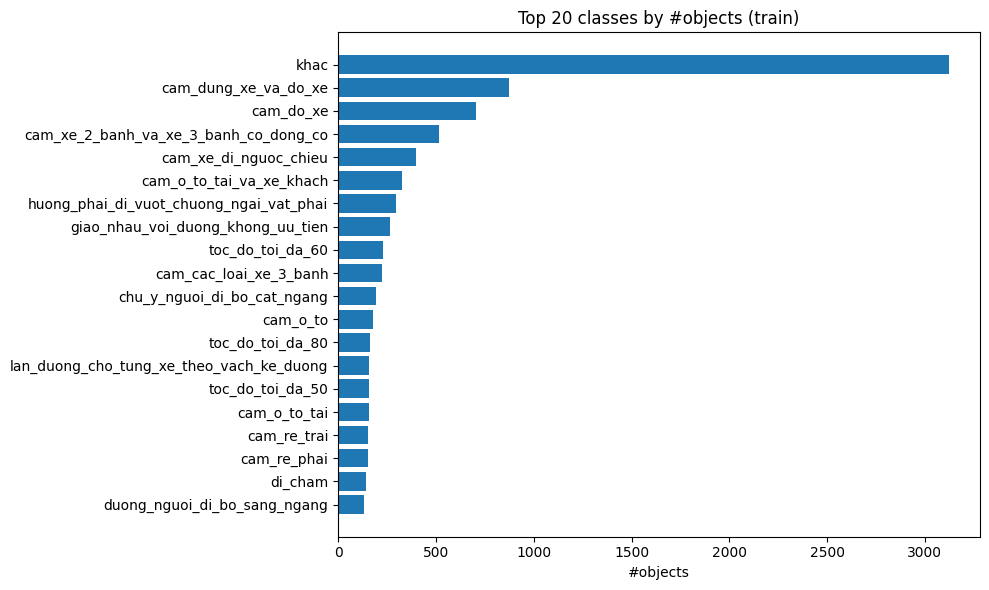

In [5]:
# =========================
# CELL 4.4: CLASS DISTRIBUTION (đếm object theo class từ YOLO labels)
# =========================
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt

DATASET_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1")
YAML_FIXED = DATASET_DIR / "data_fixed.yaml"

# 1) Load names từ YAML fixed
with open(YAML_FIXED, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

names = data["names"]  # list tên class theo index
nc = data["nc"]

# 2) Đọc labels train
train_labels_dir = DATASET_DIR / "train" / "labels"
label_files = sorted(train_labels_dir.glob("*.txt"))

counts = [0] * nc
total_boxes = 0
empty_labels = 0

for lf in label_files:
    lines = lf.read_text(encoding="utf-8").strip().splitlines()
    if len(lines) == 0:
        empty_labels += 1
        continue
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(float(parts[0]))
        if 0 <= cls < nc:
            counts[cls] += 1
            total_boxes += 1

df = pd.DataFrame({
    "class_id": list(range(nc)),
    "class_name": names,
    "num_objects": counts
}).sort_values("num_objects", ascending=False)

print("✅ Số file label (train):", len(label_files))
print("✅ Số label rỗng (train):", empty_labels)
print("✅ Tổng số bbox (train):", total_boxes)

# 3) In nhanh top 15 class
display(df.head(15))

# 4) Vẽ top 20 class (cho dễ nhìn)
topk = 20
plot_df = df.head(topk).iloc[::-1]  # đảo để vẽ đẹp (ít -> nhiều từ dưới lên)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["class_name"], plot_df["num_objects"])
plt.title(f"Top {topk} classes by #objects (train)")
plt.xlabel("#objects")
plt.tight_layout()
plt.show()

Cell 4.5 (1 cell) — In cấu hình train + đường dẫn YAML (YOLO26 + RAM-safe)

In [6]:
# =========================
# CELL 4.5: GỢI Ý HYPERPARAMETERS (YOLO26 + RAM-safe)
# =========================
from pathlib import Path
import ultralytics

print("Ultralytics version:", ultralytics.__version__)

DATASET_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1")
DATA_YAML = DATASET_DIR / "data_fixed.yaml"

train_cfg = dict(
    model="yolo26n.pt",          # YOLO26 nano pretrained
    data=str(DATA_YAML),         # dùng YAML đã fix path
    imgsz=640,
    epochs=200,
    batch=2,                     # RAM-safe (RTX 3050 4GB + tránh low-memory)
    optimizer="auto",
    cos_lr=True,
    patience=25,                 # early stop (sẽ chỉnh tiếp ở cell 4.5b nếu muốn)
    mosaic=0.8,                  # nhẹ hơn 1.0 nhưng vẫn hiệu quả
    mixup=0.0,                   # tắt để tránh MemoryError / low RAM
    erasing=0.0,                 # tắt để nhẹ RAM
    copy_paste=0.0,
    device=0,
    name="vietnam_traffic_y26n",
)

print("✅ DATA_YAML =", DATA_YAML)
print("\n=== TRAIN CONFIG (đề xuất) ===")
for k, v in train_cfg.items():
    print(f"{k:12s}: {v}")

Ultralytics version: 8.4.5
✅ DATA_YAML = d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml

=== TRAIN CONFIG (đề xuất) ===
model       : yolo26n.pt
data        : d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml
imgsz       : 640
epochs      : 200
batch       : 2
optimizer   : auto
cos_lr      : True
patience    : 25
mosaic      : 0.8
mixup       : 0.0
erasing     : 0.0
copy_paste  : 0.0
device      : 0
name        : vietnam_traffic_y26n


Cell 4.5b — Early stopping (patience=25)

In [7]:
# =========================
# CELL 4.5b: EARLY STOPPING (patience)
# =========================
train_cfg["patience"] = 25
print("✅ Updated patience =", train_cfg["patience"])

✅ Updated patience = 25


Cell 4.6 (1 cell) — close_mosaic=10 + augmentation (giữ an toàn biển báo)

In [8]:
# =========================
# CELL 4.6: TĂNG ĐỘ CHÍNH XÁC (augmentation + fine-tune cuối)
# =========================

# Tắt mosaic 10 epoch cuối để fine-tune ổn định hơn
train_cfg["close_mosaic"] = 10

# Augmentation mức vừa phải (hợp traffic signs)
train_cfg.update(dict(
    hsv_h=0.015,
    hsv_s=0.70,
    hsv_v=0.40,
    degrees=5.0,
    translate=0.10,
    scale=0.50,
    shear=0.0,
    perspective=0.0,
    fliplr=0.0,   # tránh lật làm đổi ý nghĩa biển
    flipud=0.0,
))

print("✅ Updated TRAIN CONFIG (4.6):")
for k, v in train_cfg.items():
    print(f"{k:12s}: {v}")

✅ Updated TRAIN CONFIG (4.6):
model       : yolo26n.pt
data        : d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml
imgsz       : 640
epochs      : 200
batch       : 2
optimizer   : auto
cos_lr      : True
patience    : 25
mosaic      : 0.8
mixup       : 0.0
erasing     : 0.0
copy_paste  : 0.0
device      : 0
name        : vietnam_traffic_y26n
close_mosaic: 10
hsv_h       : 0.015
hsv_s       : 0.7
hsv_v       : 0.4
degrees     : 5.0
translate   : 0.1
scale       : 0.5
shear       : 0.0
perspective : 0.0
fliplr      : 0.0
flipud      : 0.0


Cell 4.7b (1 cell) — Train (workers=0 + lưu runs trong project)

In [9]:
# =========================
# CELL 4.7b: TRAIN YOLO26 (RAM-safe + Windows ổn định)
# =========================
from pathlib import Path
import os
from ultralytics import YOLO

# 1) Đưa notebook về đúng project root
PROJECT_ROOT = Path(r"d:\Documents\yolo11_vn_traffic_sign")
os.chdir(PROJECT_ROOT)
print("✅ CWD =", Path.cwd())

# 2) Update config: workers=0 + lưu runs trong project
train_cfg["workers"] = 0
train_cfg["project"] = str(PROJECT_ROOT / "runs")
train_cfg["exist_ok"] = True
train_cfg["name"] = "vietnam_traffic_y26n_w0"

# 3) Train
model = YOLO(train_cfg["model"])
results = model.train(
    data=train_cfg["data"],
    imgsz=train_cfg["imgsz"],
    epochs=train_cfg["epochs"],
    batch=train_cfg["batch"],
    optimizer=train_cfg["optimizer"],
    cos_lr=train_cfg["cos_lr"],
    patience=train_cfg["patience"],
    mosaic=train_cfg["mosaic"],
    close_mosaic=train_cfg["close_mosaic"],
    mixup=train_cfg["mixup"],
    erasing=train_cfg["erasing"],
    copy_paste=train_cfg["copy_paste"],
    hsv_h=train_cfg["hsv_h"],
    hsv_s=train_cfg["hsv_s"],
    hsv_v=train_cfg["hsv_v"],
    degrees=train_cfg["degrees"],
    translate=train_cfg["translate"],
    scale=train_cfg["scale"],
    shear=train_cfg["shear"],
    perspective=train_cfg["perspective"],
    fliplr=train_cfg["fliplr"],
    flipud=train_cfg["flipud"],
    device=train_cfg["device"],
    workers=train_cfg["workers"],
    project=train_cfg["project"],
    name=train_cfg["name"],
    exist_ok=train_cfg["exist_ok"],
)

✅ CWD = d:\Documents\yolo11_vn_traffic_sign
New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.5  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, 

Cell 4.8 (1 cell) — Validate + in metrics chính

In [10]:
# =========================
# CELL 4.8: ĐÁNH GIÁ (VAL) - YOLO26 best.pt
# =========================
from pathlib import Path
from ultralytics import YOLO

RUN_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0")
BEST_PT = RUN_DIR / "weights" / "best.pt"

print("✅ best.pt exists:", BEST_PT.exists(), "-", BEST_PT)

model = YOLO(str(BEST_PT))

metrics = model.val(
    data=r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml",
    imgsz=640,
    device=0
)

# In nhanh metrics tổng quan (Ultralytics sẽ in log, đây là phần tóm tắt thêm)
try:
    print("\n=== SUMMARY (overall) ===")
    print("mAP50     :", float(metrics.box.map50))
    print("mAP50-95  :", float(metrics.box.map))
    print("Precision :", float(metrics.box.mp))
    print("Recall    :", float(metrics.box.mr))
except Exception as e:
    print("Không đọc được metrics object theo thuộc tính quen thuộc, nhưng log phía trên đã có đầy đủ.")
    print("Error:", e)

✅ best.pt exists: True - d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0\weights\best.pt
Ultralytics 8.4.5  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,385,366 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 5.61.5 MB/s, size: 56.2 KB)
val: Scanning D:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\valid\labels.cache... 305 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 305/305  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 4.8it/s 4.2s0.1s
                   all        305        932      0.834      0.668      0.757      0.572
cam_cac_loai_xe_3_banh         17         19       0.97      0.789       0.87      0.723
             cam_do_xe         65         67      0.889      0.896      0.912      0.665
  cam_dung_xe_va_do_xe         63       

Cell 4.8b — Confusion matrix 54 lớp + Accuracy + Balanced Accuracy

In [11]:
# =========================
# CELL 4.8b: CONFUSION MATRIX (54 class) + ACCURACY + BALANCED ACCURACY
# =========================
from pathlib import Path
import numpy as np
from ultralytics import YOLO

RUN_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0")
BEST_PT = RUN_DIR / "weights" / "best.pt"
DATA_YAML = Path(r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\data_fixed.yaml")

print("✅ best.pt:", BEST_PT, "| exists:", BEST_PT.exists())

model = YOLO(str(BEST_PT))

# plots=True để Ultralytics xuất confusion_matrix.png (và normalized) ra save_dir
metrics = model.val(
    data=str(DATA_YAML),
    imgsz=640,
    device=0,
    plots=True
)

# 1) In đường dẫn lưu kết quả
save_dir = Path(getattr(metrics, "save_dir", RUN_DIR))
print("\n✅ save_dir:", save_dir)

# 2) Lấy confusion matrix từ metrics (tuỳ phiên bản Ultralytics, attribute có thể khác nhau)
cm = None
cm_obj = None

for attr in ["confusion_matrix", "confusion", "cm"]:
    if hasattr(metrics, attr):
        cm_obj = getattr(metrics, attr)
        break

if cm_obj is not None:
    if hasattr(cm_obj, "matrix"):
        cm = np.array(cm_obj.matrix)
    elif isinstance(cm_obj, (list, np.ndarray)):
        cm = np.array(cm_obj)

# 3) Nếu lấy được matrix thì tính Accuracy + Balanced Accuracy
if cm is None:
    print("\n⚠️ Không lấy được confusion matrix dạng số từ metrics object.")
    print("Nhưng Ultralytics đã lưu ảnh confusion matrix trong thư mục save_dir (xem danh sách bên dưới).")
else:
    # cm thường có dạng (nc+1, nc+1) với hàng/cột cuối là background
    # Suy ra nc từ shape
    nc = cm.shape[0] - 1
    bg = nc

    # Row sum theo true class (bao gồm cả cột background) => tổng GT của mỗi class
    row_sum = cm[:nc, :].sum(axis=1)
    diag = np.diag(cm[:nc, :nc])

    # Overall accuracy (micro) theo GT objects
    overall_acc = diag.sum() / (row_sum.sum() + 1e-12)

    # Per-class recall (TP / GT)
    per_class_recall = np.where(row_sum > 0, diag / (row_sum + 1e-12), np.nan)

    # Balanced accuracy = mean recall của các class có GT
    balanced_acc = np.nanmean(per_class_recall)

    # Thêm 1 chỉ số phụ: accuracy chỉ tính trên các object được predict ra class (không tính FN/background)
    # (tức là bỏ cột background khi tính mẫu số)
    classified_total = cm[:nc, :nc].sum()
    acc_on_classified = diag.sum() / (classified_total + 1e-12)

    print("\n=== CONFUSION MATRIX METRICS (val) ===")
    print(f"Overall Accuracy (micro, theo GT)      : {overall_acc:.4f}")
    print(f"Balanced Accuracy (macro recall)       : {balanced_acc:.4f}")
    print(f"Accuracy on classified (bỏ FN/bg col)  : {acc_on_classified:.4f}")

# 4) In ra các file confusion matrix đã được lưu
pngs = sorted(save_dir.glob("confusion_matrix*.png"))
print("\n✅ Confusion matrix images:")
for p in pngs:
    print(" -", p)


✅ best.pt: d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0\weights\best.pt | exists: True
Ultralytics 8.4.5  Python-3.11.9 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,385,366 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 374.7142.7 MB/s, size: 59.0 KB)
val: Scanning D:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\valid\labels.cache... 305 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 305/305  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 5.1it/s 3.9s0.2s
                   all        305        932      0.834      0.668      0.757      0.572
cam_cac_loai_xe_3_banh         17         19       0.97      0.789       0.87      0.723
             cam_do_xe         65         67      0.889      0.896      0.912      0.665
  cam_dung_xe_va_do_xe         63  

Cell 4.9 (1 cell) — Predict 5 ảnh test + show 2 ảnh

✅ best.pt exists: True
✅ test images dir: d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1\test\images | exists: True
✅ Sample images:
 - 900_jpg.rf.03594f2b5fdf8f88c130048b8f39c92b.jpg
 - 338_jpg.rf.f70a989c26d641f7edb0d9f261d64317.jpg
 - 1499_jpg.rf.b23d83e0d9e1b5efdcf8055b5f99f64a.jpg
 - 1322_jpg.rf.e77f57233d2519046343c690699e06f7.jpg
 - 844_jpg.rf.20f6a5b81e63fc382678e0c725dfff0b.jpg

0: 640x640 1 cam_do_xe, 1 cam_dung_xe_va_do_xe, 2 khacs, 48.7ms
1: 640x640 1 cam_dung_xe_va_do_xe, 1 cam_o_to_tai_va_xe_khach, 1 cam_xe_2_banh_va_xe_3_banh_co_dong_co, 2 khacs, 48.7ms
2: 640x640 1 cam_do_xe, 2 cam_xe_2_banh_va_xe_3_banh_co_dong_cos, 1 di_cham, 1 khac, 48.7ms
3: 640x640 1 cho_ngoat_nguy_hiem_ben_trai, 1 di_cham, 48.7ms
4: 640x640 1 cam_o_to_re_phai, 1 khac, 48.7ms
Speed: 9.8ms preprocess, 48.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to D:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_pred

✅ Sa

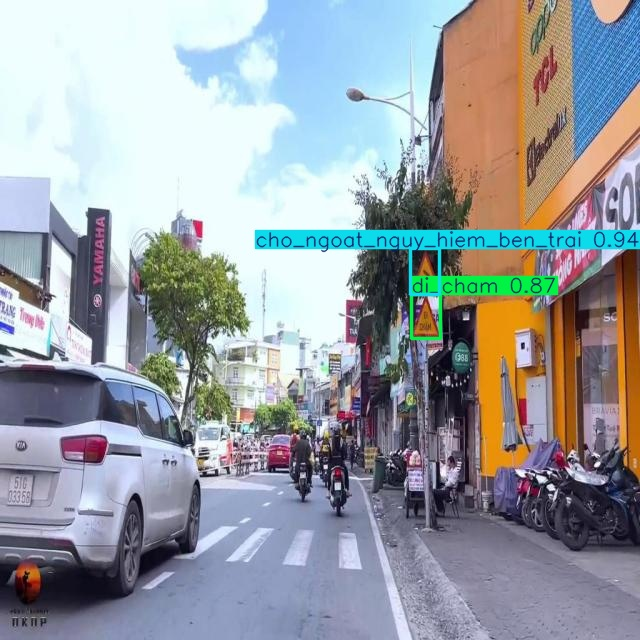

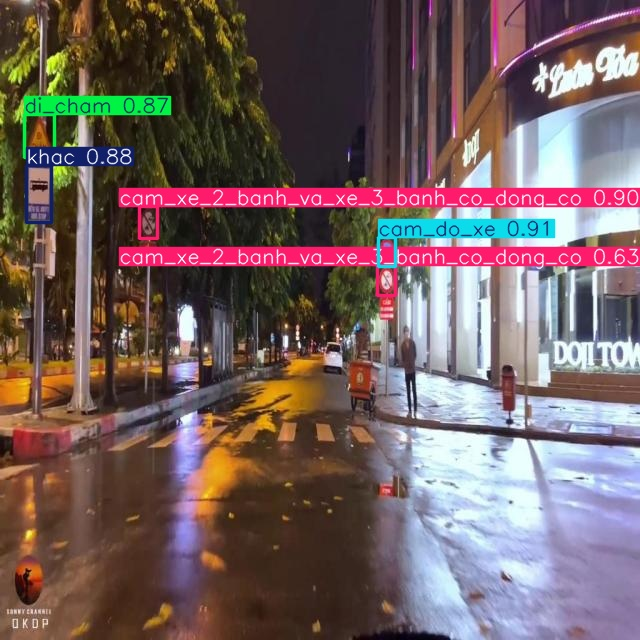

In [12]:
# =========================
# CELL 4.9: DỰ ĐOÁN MẪU TRÊN TEST SET + HIỂN THỊ KẾT QUẢ
# =========================
from pathlib import Path
import random
from ultralytics import YOLO
from PIL import Image

# Đường dẫn best model
BEST_PT = Path(r"d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0\weights\best.pt")
DATASET_DIR = Path(r"d:\Documents\yolo11_vn_traffic_sign\notebooks\datasets\datasets\Vietnam-Traffic-Sign-1")
TEST_IMG_DIR = DATASET_DIR / "test" / "images"

print("✅ best.pt exists:", BEST_PT.exists())
print("✅ test images dir:", TEST_IMG_DIR, "| exists:", TEST_IMG_DIR.exists())

# Lấy ngẫu nhiên 5 ảnh test
img_paths = sorted([p for p in TEST_IMG_DIR.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]])
sample = random.sample(img_paths, k=min(5, len(img_paths)))
print("✅ Sample images:")
for p in sample:
    print(" -", p.name)

model = YOLO(str(BEST_PT))

# Predict + save ảnh có bbox
pred_results = model.predict(
    source=[str(p) for p in sample],
    conf=0.25,
    iou=0.45,
    save=True,
    name="vietnam_traffic_y26n_pred",
    project=r"d:\Documents\yolo11_vn_traffic_sign\runs"
)

# Hiển thị 2 ảnh kết quả (Ultralytics đã vẽ bbox sẵn trong file saved)
save_dir = Path(r"d:\Documents\yolo11_vn_traffic_sign\runs") / "vietnam_traffic_y26n_pred"
print("\n✅ Saved predictions to:", save_dir)

saved_imgs = sorted([p for p in save_dir.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
print("✅ Saved files:", len(saved_imgs))

# Show 2 ảnh đầu
for p in saved_imgs[:2]:
    display(Image.open(p))


Cell 4.11a (1 cell) — Tạo file app.py Streamlit (cơ bản)

In [15]:
# =========================
# CELL 4.11-1: CÀI STREAMLIT (đúng .venv)
# =========================
import sys
import subprocess

print("Python đang dùng:", sys.executable)

subprocess.check_call([sys.executable, "-m", "pip", "install", "streamlit"])
print("✅ Installed streamlit")


Python đang dùng: d:\Documents\yolo11_vn_traffic_sign\.venv\Scripts\python.exe
✅ Installed streamlit


In [ ]:
# =========================
# CELL 4.11-2: TẠO LẠI app.py (đã fix NameError)
# =========================
from pathlib import Path

PROJECT_ROOT = Path(r"d:\Documents\yolo11_vn_traffic_sign")
APP_PATH = PROJECT_ROOT / "app.py"
MODEL_PATH = r"d:\Documents\yolo11_vn_traffic_sign\runs\vietnam_traffic_y26n_w0\weights\best.pt"

app_code = f'''\
from pathlib import Path
import streamlit as st
import cv2
from ultralytics import YOLO

st.set_page_config(page_title="Vietnam Traffic Sign - YOLO26", layout="wide")
st.title("🚦 Vietnam Traffic Sign Detection (YOLO26n)")
st.caption("Demo cơ bản: upload ảnh hoặc video (.mp4) → detect → hiển thị kết quả")

MODEL_PATH = r"{MODEL_PATH}"
TMP_DIR = Path("tmp")
OUT_DIR = Path("runs_streamlit")
TMP_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

@st.cache_resource
def load_model():
    return YOLO(MODEL_PATH)

model = load_model()

conf = st.sidebar.slider("Confidence", 0.05, 0.95, 0.25, 0.05)
iou  = st.sidebar.slider("IoU",        0.10, 0.90, 0.45, 0.05)

uploaded = st.file_uploader("Chọn ảnh hoặc video", type=["jpg","jpeg","png","webp","mp4"])

if uploaded is None:
    st.info("Hãy upload 1 ảnh hoặc video để bắt đầu.")
    st.stop()

suffix = Path(uploaded.name).suffix.lower()
input_path = TMP_DIR / f"input{{suffix}}"
with open(input_path, "wb") as f:
    f.write(uploaded.getbuffer())

col1, col2 = st.columns(2)

if suffix in [".jpg", ".jpeg", ".png", ".webp"]:
    # ===== IMAGE =====
    img_bgr = cv2.imread(str(input_path))
    if img_bgr is None:
        st.error("Không đọc được ảnh. Hãy thử ảnh khác.")
        st.stop()

    with col1:
        st.subheader("Ảnh gốc")
        st.image(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), use_container_width=True)

    res = model.predict(source=str(input_path), conf=conf, iou=iou, verbose=False)[0]
    annotated = res.plot()  # BGR numpy

    with col2:
        st.subheader("Kết quả detect")
        st.image(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB), use_container_width=True)

else:
    # ===== VIDEO =====
    with col1:
        st.subheader("Video gốc")
        st.video(str(input_path))

    name = "pred_video"
    _ = model.predict(
        source=str(input_path),
        conf=conf,
        iou=iou,
        save=True,
        project=str(OUT_DIR),
        name=name,
        exist_ok=True,
        verbose=False
    )

    out_folder = OUT_DIR / name
    out_video = None
    for ext in [".mp4", ".avi", ".mov", ".mkv"]:
        cand = list(out_folder.glob(f"*{{ext}}"))
        if cand:
            out_video = cand[0]
            break

    with col2:
        st.subheader("Video kết quả (annotated)")
        if out_video and out_video.exists():
            st.video(str(out_video))
            st.write("Output:", str(out_video))
        else:
            st.warning("Không tìm thấy video output. Kiểm tra folder: " + str(out_folder))
'''

APP_PATH.write_text(app_code, encoding="utf-8")
print("✅ Wrote:", APP_PATH)
print(r"➡️ Run: .\.venv\Scripts\python.exe -m streamlit run app.py")
